# Notebook 1: Análise Exploratória de Dados (EDA) e Pré-Processamento
### Projeto Final de Licenciatura - Sistemas de Apoio à Decisão Clínica

**Autor:** Gustavo P. Vília  
**Âmbito:** Transparência em Sistemas de Apoio à Decisão Clínica: Impacto da Inteligência Artificial Explicável na Triagem Radiológica

---

## 🎯 Objetivo deste Notebook
O presente documento constitui a primeira fase prática da construção do artefacto tecnológico. O objetivo principal deste *notebook* é importar, analisar e preparar a base de dados (o *NIH Chest X-Ray Dataset*) para o posterior treino da rede neuronal. Devido à elevada volumetria dos dados originais (mais de 112 mil imagens radiográficas e ~42GB de tamanho), esta fase foca-se na otimização computacional e na filtragem estratégica.

## 📋 Etapas Principais:
1. **Configuração de Ambiente:** Ligação à API do Kaggle para extração direta e otimizada dos dados para a máquina virtual, contornando limitações de armazenamento local.
2. **Análise Exploratória (EDA):** Verificação estatística dos metadados clínicos e identificação visual do problema estrutural do conjunto de dados: o severo **desequilíbrio de classes** (*class imbalance*).
3. **Filtragem de Dados:** Delimitação do âmbito de classificação para Nódulos e Massas (com grupo de controlo saudável), de forma a garantir uma validação posterior fiável através do Grad-CAM.
4. **Pré-Processamento:** Preparação matemática das imagens (redimensionamento para 224x224 píxeis e normalização) e configuração dos geradores de *Data Augmentation*.

*Nota: O output final deste notebook será um conjunto de dados estruturado e limpo, pronto a ser ingerido pela arquitetura DenseNet121 no Notebook 2.*

## 1. Importação Otimizada do Dataset (KaggleHub)
Para colmatar as limitações de memória volátil (RAM e Disco) do ambiente Google Colab, optou-se por utilizar a biblioteca moderna kagglehub para a extração dos dados. Em vez de importar o dataset original com resolução de 1024x1024 píxeis (aproximadamente 42GB), importa-se uma versão do repositório já otimizada e pré-redimensionada para 224x224 píxeis. Esta decisão arquitetural permite acelerar drasticamente o tempo de I/O (Input/Output) e cumpre antecipadamente os requisitos de input da rede DenseNet121, reduzindo a sobrecarga computacional na fase de pré-processamento.

In [1]:
# 1. Instalar a biblioteca kagglehub (caso o Colab não tenha a versão mais recente)
!pip install -q kagglehub

import kagglehub
import os

# 2. Fazer o download do dataset pré-redimensionado (224x224)
print("A iniciar o download do dataset otimizado via KaggleHub...")
caminho_dataset = kagglehub.dataset_download("khanfashee/nih-chest-x-ray-14-224x224-resized")

print(f"\n✅ Download concluído com sucesso!")
print(f"📁 Os dados foram guardados no caminho temporário: {caminho_dataset}")

# 3. Listar os ficheiros que vieram lá dentro para confirmarmos o nome do CSV
print("\nConteúdo da pasta do dataset:")
print(os.listdir(caminho_dataset))

A iniciar o download do dataset otimizado via KaggleHub...


100%|██████████| 2.30G/2.30G [02:23<00:00, 17.2MB/s]

Extracting files...



✅ Download concluído com sucesso!
📁 Os dados foram guardados no caminho temporário: /root/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3

Conteúdo da pasta do dataset:
['pretrained_model.h5', 'train_val_list_NIH.txt', 'BBox_List_2017_Official_NIH.csv', 'test_list_NIH.txt', 'Data_Entry_2017.csv', 'images-224']


## 2. Análise Exploratória de Dados (EDA): Desequilíbrio de Classes

O passo seguinte incide na validação empírica do desequilíbrio estrutural inerente ao dataset NIH. Através da biblioteca Pandas, efetuamos a leitura do ficheiro de metadados (Data_Entry_2017.csv). Dado o caráter multirrótulo da base de dados (onde um único paciente pode apresentar doenças concomitantes separadas pelo delimitador |), implementamos um algoritmo de filtragem para contabilizar a frequência absoluta de cada patologia individual. O output visual desta análise um gráfico de barras ordenado materializa a justificação clínica para a posterior restrição do modelo às classes de Nódulo e Massa, conforme preconizado na metodologia do projeto.

Total de Raios-X lidos: 112120


/tmp/ipykernel_25465/3548432005.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequência', y='Patologia', data=df_contagem, palette='magma')


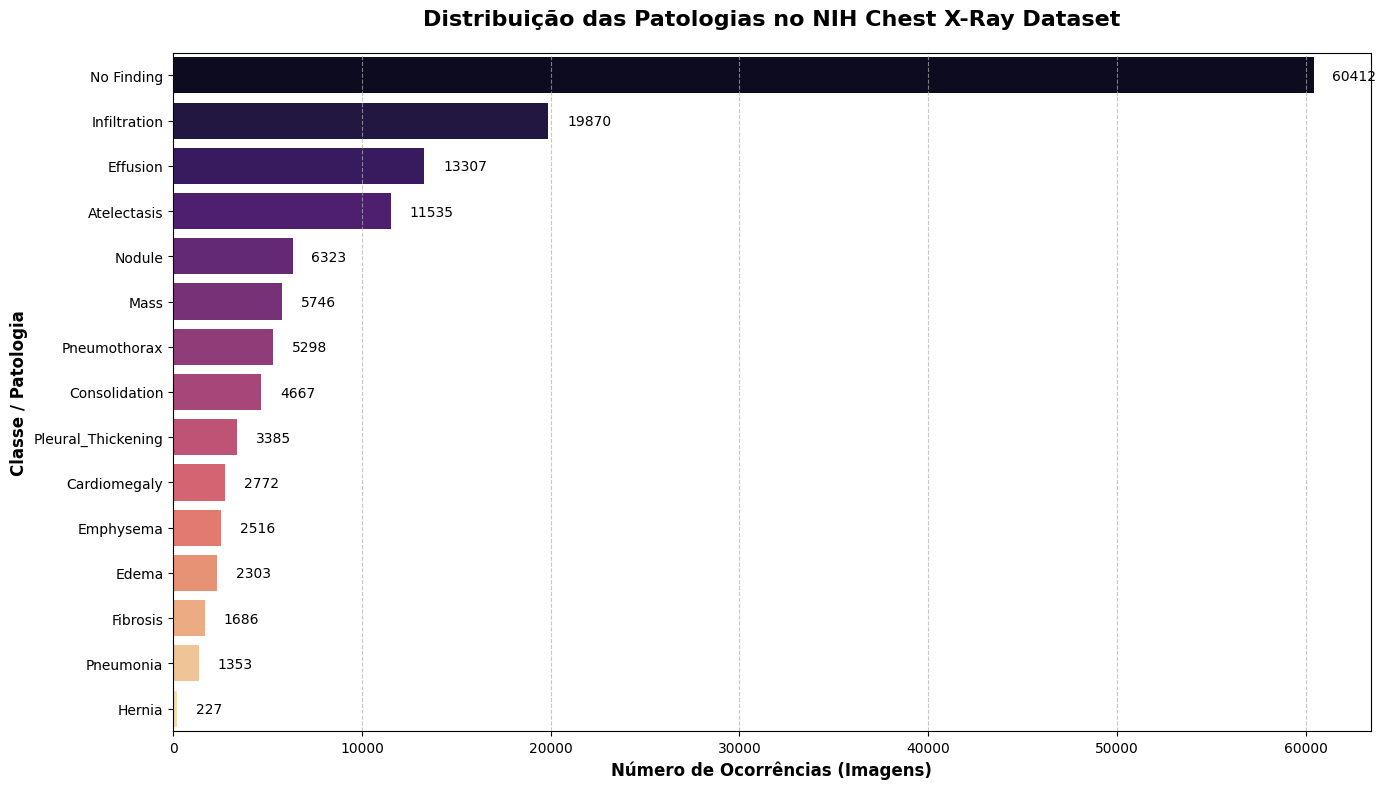

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# 1. Definir o caminho exato para o ficheiro CSV com base no download do Kagglehub
# Usamos a variável 'caminho_dataset' que criaste na célula anterior
caminho_csv = os.path.join(caminho_dataset, 'Data_Entry_2017.csv')

# Ler o ficheiro para a memória do Pandas
df = pd.read_csv(caminho_csv)
print(f"Total de Raios-X lidos: {len(df)}")

# 2. Processar a coluna 'Finding Labels'
# O lambda divide strings como "Nodule|Pneumonia" e o concatenate junta tudo
todas_labels = np.concatenate(df['Finding Labels'].apply(lambda x: x.split('|')).values)
contagem_doencas = Counter(todas_labels)

# 3. Preparar um DataFrame para facilitar a plotagem do gráfico
df_contagem = pd.DataFrame.from_dict(contagem_doencas, orient='index', columns=['Frequência']).reset_index()
df_contagem = df_contagem.rename(columns={'index': 'Patologia'}).sort_values(by='Frequência', ascending=False)

# 4. Gerar o Gráfico de Barras (Formatado para o Relatório)
plt.figure(figsize=(14, 8))
# Paleta de cores forte e profissional
sns.barplot(x='Frequência', y='Patologia', data=df_contagem, palette='magma')

# Títulos e labels de eixo
plt.title('Distribuição das Patologias no NIH Chest X-Ray Dataset', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Ocorrências (Imagens)', fontsize=12, fontweight='bold')
plt.ylabel('Classe / Patologia', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionar os números exatos à frente de cada barra
for i, v in enumerate(df_contagem['Frequência']):
    plt.text(v + 1000, i + 0.1, str(v), color='black', fontsize=10)

plt.tight_layout()
# Mostrar o gráfico final
plt.show()

## 3. Filtragem e Balanceamento do Dataset (Undersampling)

Comprovado o acentuado desequilíbrio das classes originais, esta etapa implementa o protocolo de mitigação definido na metodologia do projeto. Primeiramente, isolamos as duas categorias de interesse (radiografias estritamente saudáveis e radiografias com Nódulos ou Massas). De seguida, aplicamos uma técnica de Undersampling aleatório à classe maioritária ("No Finding"). Esta operação reduz o número de casos de controlo para corresponder exatamente ao número de casos patológicos detetados. O resultado é um subset de dados perfeitamente equilibrado (50/50), garantindo que a Rede Neuronal Convolucional não desenvolva um viés em direção à classe dominante, otimizando assim a Sensibilidade (taxa de verdadeiros positivos) do modelo final.

Total de Saudáveis (Original): 60412
Total de Doentes (Original): 11175
------------------------------
✅ DATASET BALANCEADO CRIADO COM SUCESSO!
Total final de imagens para treino: 22350
Rotulo
Saudável        11175
Nódulo/Massa    11175
Name: count, dtype: int64


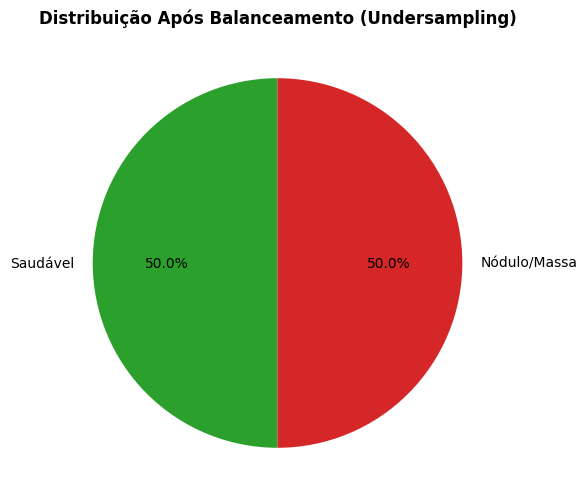

In [3]:
# 1. Isolar os casos estritamente saudáveis (Classe 0)
df_saudaveis = df[df['Finding Labels'] == 'No Finding'].copy()
df_saudaveis['Classe_Binaria'] = 0
df_saudaveis['Rotulo'] = 'Saudável'

# 2. Isolar os casos com Nódulos ou Massas (Classe 1)
# O str.contains garante que apanhamos casos mesmo que tenham outras doenças misturadas
df_doentes = df[df['Finding Labels'].str.contains('Nodule|Mass')].copy()
df_doentes['Classe_Binaria'] = 1
df_doentes['Rotulo'] = 'Nódulo/Massa'

print(f"Total de Saudáveis (Original): {len(df_saudaveis)}")
print(f"Total de Doentes (Original): {len(df_doentes)}")

# 3. Aplicar o Undersampling (Balanceamento)
# Vamos extrair amostras aleatórias dos saudáveis para igualar o número de doentes
numero_de_doentes = len(df_doentes)
df_saudaveis_balanceado = df_saudaveis.sample(n=numero_de_doentes, random_state=42)

# 4. Juntar os dois grupos num único DataFrame final
df_final = pd.concat([df_saudaveis_balanceado, df_doentes])

# 5. Baralhar as linhas para que o modelo não leia tudo por ordem durante o treino
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print("-" * 30)
print(f"✅ DATASET BALANCEADO CRIADO COM SUCESSO!")
print(f"Total final de imagens para treino: {len(df_final)}")
print(df_final['Rotulo'].value_counts())

# Gerar um pequeno gráfico circular para comprovar o balanceamento
plt.figure(figsize=(6, 6))
plt.pie(df_final['Rotulo'].value_counts(), labels=df_final['Rotulo'].unique(),
        autopct='%1.1f%%', colors=['#2ca02c', '#d62728'], startangle=90)
plt.title('Distribuição Após Balanceamento (Undersampling)', fontweight='bold')
plt.show()

## 4. Mapeamento de Diretórios e Divisão do Dataset (Holdout)

Com as classes rigorosamente balanceadas, o passo seguinte consiste em estabelecer a ponte entre os metadados tabulares e os ficheiros físicos das imagens. Para tal, constrói-se o caminho absoluto de cada radiografia através da coluna Image Index. De seguida, aplica-se a técnica de separação Holdout estruturada em 70% para Treino, 15% para Validação e 15% para Teste. É fundamental salientar o uso do parâmetro de estratificação (stratify), que assegura que a proporção perfeita de 50/50 entre classes saudáveis e patológicas seja escrupulosamente mantida em todos os subconjuntos gerados.

In [4]:
from sklearn.model_selection import train_test_split

# 1. Mapear o caminho completo de cada imagem no disco do Colab
pasta_imagens = os.path.join(caminho_dataset, 'images-224')
df_final['Caminho_Imagem'] = df_final['Image Index'].apply(lambda x: os.path.join(pasta_imagens, x))

# 2. Garantir que os rótulos são strings (exigência técnica do gerador do Keras)
df_final['Rotulo'] = df_final['Rotulo'].astype(str)

# 3. Divisão Estratificada dos Dados
# Primeiro: 70% para Treino e 30% para Validação/Teste
df_treino, df_temp = train_test_split(
    df_final,
    test_size=0.30,
    random_state=42,
    stratify=df_final['Rotulo'] # Isto garante o 50/50 em cada caixote
)

# Segundo: Dividir os 30% restantes a meio (15% Validação, 15% Teste)
df_val, df_teste = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=42,
    stratify=df_temp['Rotulo']
)

print("-" * 40)
print(f"📊 SEPARAÇÃO DO DATASET CONCLUÍDA:")
print("-" * 40)
print(f"Imagens de Treino: {len(df_treino)} ({(len(df_treino)/len(df_final))*100:.0f}%)")
print(f"Imagens de Validação: {len(df_val)} ({(len(df_val)/len(df_final))*100:.0f}%)")
print(f"Imagens de Teste: {len(df_teste)} ({(len(df_teste)/len(df_final))*100:.0f}%)")

# Vamos só confirmar se a estratificação correu bem (ver as percentagens de Nódulo/Massa no Teste)
print("\nDistribuição no subset de TESTE:")
print(df_teste['Rotulo'].value_counts(normalize=True))

----------------------------------------
📊 SEPARAÇÃO DO DATASET CONCLUÍDA:
----------------------------------------
Imagens de Treino: 15645 (70%)
Imagens de Validação: 3352 (15%)
Imagens de Teste: 3353 (15%)

Distribuição no subset de TESTE:
Rotulo
Nódulo/Massa    0.500149
Saudável        0.499851
Name: proportion, dtype: float64


## 5. Pré-Processamento e Aumento de Dados (Data Augmentation)

A etapa final de preparação de dados consiste na instanciação dos geradores de imagem (ImageDataGenerator do Keras). O gerador de Treino é configurado com técnicas de Data Augmentation (rotação de 15 graus, ajustes de zoom e espelhamento horizontal) para introduzir variabilidade sintética e combater o overfitting. Em rigoroso cumprimento dos critérios anatómicos estabelecidos na metodologia, o espelhamento vertical é desativado. Adicionalmente, todos os geradores (Treino, Validação e Teste) aplicam uma normalização aos píxeis (rescale=1./255), comprimindo os valores de intensidade para o intervalo contínuo [0, 1]. Salienta-se que os conjuntos de Validação e Teste não sofrem qualquer alteração geométrica, garantindo que o modelo é avaliado com radiografias reais e inalteradas.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import files
import zipfile

# 1. Configurar os Geradores (As "fábricas" de imagens)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

TAMANHO_IMAGEM = (224, 224)
TAMANHO_LOTE = 32

print("A preparar o Gerador de Treino...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_treino,
    x_col='Caminho_Imagem',
    y_col='Rotulo',
    target_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE,
    class_mode='binary'
)

print("\nA preparar o Gerador de Validação...")
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='Caminho_Imagem',
    y_col='Rotulo',
    target_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE,
    class_mode='binary',
    shuffle=False
)

print("\nA preparar o Gerador de Teste...")
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_teste,
    x_col='Caminho_Imagem',
    y_col='Rotulo',
    target_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE,
    class_mode='binary',
    shuffle=False
)

print("-" * 40)
print("✅ NOTEBOOK 1 CONCLUÍDO COM SUCESSO!")

# 3. Exportar os CSVs para a máquina local num ficheiro ZIP
print("\nA comprimir os dados limpos num ficheiro ZIP...")

# Guardar os CSVs temporariamente no disco do Colab
df_treino.to_csv('df_treino_limpo.csv', index=False)
df_val.to_csv('df_val_limpo.csv', index=False)
df_teste.to_csv('df_teste_limpo.csv', index=False)

# Criar o ficheiro ZIP
nome_zip = 'datasets_limpos_projeto.zip'
with zipfile.ZipFile(nome_zip, 'w') as zipf:
    zipf.write('df_treino_limpo.csv')
    zipf.write('df_val_limpo.csv')
    zipf.write('df_teste_limpo.csv')

print("A iniciar o download para o teu computador...")
files.download(nome_zip)

A preparar o Gerador de Treino...
Found 0 validated image filenames belonging to 0 classes.

A preparar o Gerador de Validação...
Found 0 validated image filenames belonging to 0 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 15645 invalid image filename(s) in x_col="Caminho_Imagem". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 3352 invalid image filename(s) in x_col="Caminho_Imagem". These filename(s) will be ignored.
  warnings.warn(



A preparar o Gerador de Teste...
Found 0 validated image filenames belonging to 0 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 3353 invalid image filename(s) in x_col="Caminho_Imagem". These filename(s) will be ignored.
  warnings.warn(


----------------------------------------
✅ NOTEBOOK 1 CONCLUÍDO COM SUCESSO!

A comprimir os dados limpos num ficheiro ZIP...
A iniciar o download para o teu computador...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>